In [54]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

# from mis_dro.plot import flexible_figure


In [55]:
experiment_dir = Path("/dcs/pg23/u1604520/misdro")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "normal_bayes_newsvendor.csv", index_col=["uuid", "replication"])


# base_path = "/dcs/large/u1508153/misdro/normal_bayes_newsvendor"

# # load BDRO results and remember to filter (temporary hack for now)
# results_df = pd.read_csv(Path(base_path) / "results.csv", index_col=["uuid", "replication"])
# results_df = results_df.loc[results_df["algorithm"] == "kl_bdro"]

# for setting in ["10000", "10_10", "20_20", "30_30", "50_50"]:
#     experiment_dir = Path(base_path + "_" + setting)
#     assert experiment_dir.exists()
#     df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
#     results_df = pd.concat([results_df, df])

num_total_samples = []
for _, row in results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "our_kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"])
results_df["num_total_samples"] = num_total_samples

results_df

mean_cost     var_cost  \
uuid                                 replication                           
37eeba6a-73ac-420e-ab30-37c857775adc 0            36.436789   639.420992   
                                     1            33.281338   728.528721   
                                     2            40.117484  1119.197381   
                                     3            34.616122   761.561539   
                                     4            35.734344   528.910402   
...                                                     ...          ...   
fbf16750-802a-401f-85ed-3c3321b9364e 195          35.494315   569.388895   
                                     196          40.219034   393.644314   
                                     197          35.836101   697.886412   
                                     198          35.099532   345.762851   
                                     199          45.075313   529.324208   

                                                   solution  dgp_time  \
uuid                                 replication                        
37eeba6a-73ac-420e-ab30-37c857775adc 0            32.053977  0.000240   
                                     1            30.624625  0.000446   
                                     2            28.622687  0.000485   
                                     3            33.286875  0.000484   
                                     4            34.235903  0.000412   
...                                                     ...       ...   
fbf16750-802a-401f-85ed-3c3321b9364e 195          21.718834  0.000648   
                                     196          23.202384  0.001214   
                                     197          24.203212  0.000845   
                                     198          22.081607  0.000627   
                                     199          28.206561  0.000630   

                                                  likelihood_time  \
uuid                                 replication                    
37eeba6a-73ac-420e-ab30-37c857775adc 0                   0.000022   
                                     1                   0.000030   
                                     2                   0.000034   
                                     3                   0.000031   
                                     4                   0.000040   
...                                                           ...   
fbf16750-802a-401f-85ed-3c3321b9364e 195                 0.000157   
                                     196                 0.000157   
                                     197                 0.000209   
                                     198                 0.000095   
                                     199                 0.000097   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
37eeba6a-73ac-420e-ab30-37c857775adc 0                  0.000080    0.040731   
                                     1                  0.000143    0.031963   
                                     2                  0.000140    0.030016   
                                     3                  0.000155    0.041747   
                                     4                  0.000142    0.033874   
...                                                          ...         ...   
fbf16750-802a-401f-85ed-3c3321b9364e 195                0.000301    0.236180   
                                     196                0.000333    0.235823   
                                     197                0.000420    0.232838   
                                     198                0.000206    0.234719   
                                     199                0.000195    0.216997   

                                                  setup_time    algorithm  \
uuid                                 replication                            
37eeba6a-73ac-420e

In [56]:
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
# from mis_dro.dataset import sample_dgp
# from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_kl_bdro_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)

dgp = "normal"
posterior = "normal_gamma"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution
opt_sol

31.045853465832373

In [57]:
results_df = results_df.loc[results_df["dgp"] == 'normal']
results_df = results_df[["solution", "algorithm", "epsilon", "num_likelihood_samples", "num_posterior_samples"]]
results_df["se"] = (results_df["solution"] - opt_sol)**2
results_df

solution    algorithm  \
uuid                                 replication                           
37eeba6a-73ac-420e-ab30-37c857775adc 0            32.053977  our_kl_bdro   
                                     1            30.624625  our_kl_bdro   
                                     2            28.622687  our_kl_bdro   
                                     3            33.286875  our_kl_bdro   
                                     4            34.235903  our_kl_bdro   
...                                                     ...          ...   
86353fb5-3c03-429d-ae98-451137aa0368 195          36.987371      kl_bdro   
                                     196          33.823548      kl_bdro   
                                     197          37.645046      kl_bdro   
                                     198          34.568594      kl_bdro   
                                     199          40.313952      kl_bdro   

                                                  epsilon  \
uuid                                 replication            
37eeba6a-73ac-420e-ab30-37c857775adc 0               0.05   
                                     1               0.05   
                                     2               0.05   
                                     3               0.05   
                                     4               0.05   
...                                                   ...   
86353fb5-3c03-429d-ae98-451137aa0368 195             3.00   
                                     196             3.00   
                                     197             3.00   
                                     198             3.00   
                                     199             3.00   

                                                  num_likelihood_samples  \
uuid                                 replication                           
37eeba6a-73ac-420e-ab30-37c857775adc 0                                25   
                                     1                                25   
                                     2                                25   
                                     3                                25   
                                     4                                25   
...                                                                  ...   
86353fb5-3c03-429d-ae98-451137aa0368 195                              30   
                                     196                              30   
                                     197                              30   
                                     198                              30   
                                     199                              30   

                                                  num_posterior_samples  \
uuid                                 replication                          
37eeba6a-73ac-420e-ab30-37c857775adc 0                                1   
                                     1                                1   
                                     2                                1   
                                     3                                1   
                                     4                                1   
...                                                                 ...   
86353fb5-3c03-429d-ae98-451137aa0368 195                             30   
                                     196                             30   
                                     197                             30   
                                     198                             30   
                                     199                             30   

                                                         se  
uuid                                 replication             
37eeba6a-73ac-420e-ab30-37c857775adc 0             1.016313  
                                     1             0.177433  
                                     2             5.87

In [58]:
gb = results_df.groupby(by=["algorithm", "epsilon", "num_likelihood_samples", "num_posterior_samples"])
# agg_df = gb.agg({
#     "mean_cost": ["mean", "var"],
#     "var_cost": ["mean"],
#     "posterior_time": ["mean"],
#     "setup_time": ["mean"],
#     "solve_time": ["mean"],
#     "solution": ["mean", "var"],
# })
# agg_df
agg_df = gb.agg({"se": ["mean", "std"]})
agg_df

se  \
                                                                       mean   
algorithm   epsilon num_likelihood_samples num_posterior_samples              
kl_bdro     0.05    5                      5                      17.949659   
                    10                     10                     11.989696   
                    30                     30                      9.739607   
            0.06    5                      5                      18.113425   
                    10                     10                     12.207689   
...                                                                     ...   
our_kl_bdro 2.50    100                    1                      52.980605   
                    900                    1                      83.563810   
            3.00    25                     1                      30.748583   
                    100                    1                      53.936960   
                    900                    1                      92.248452   

                                                                             
                                                                        std  
algorithm   epsilon num_likelihood_samples num_posterior_samples             
kl_bdro     0.05    5                      5                      25.632580  
                    10                     10                     18.471212  
                    30                     30                     14.186471  
            0.06    5                      5                      25.848209  
                    10                     10                     18.759281  
...                                                                     ...  
our_kl_bdro 2.50    100                    1                      59.094632  
                    900                    1                      65.333313  
            3.00    25                     1                      45.174881  
                    100                    1                      60.408339  
                    900                    1                      71.031779  

[126 rows x 2 columns]

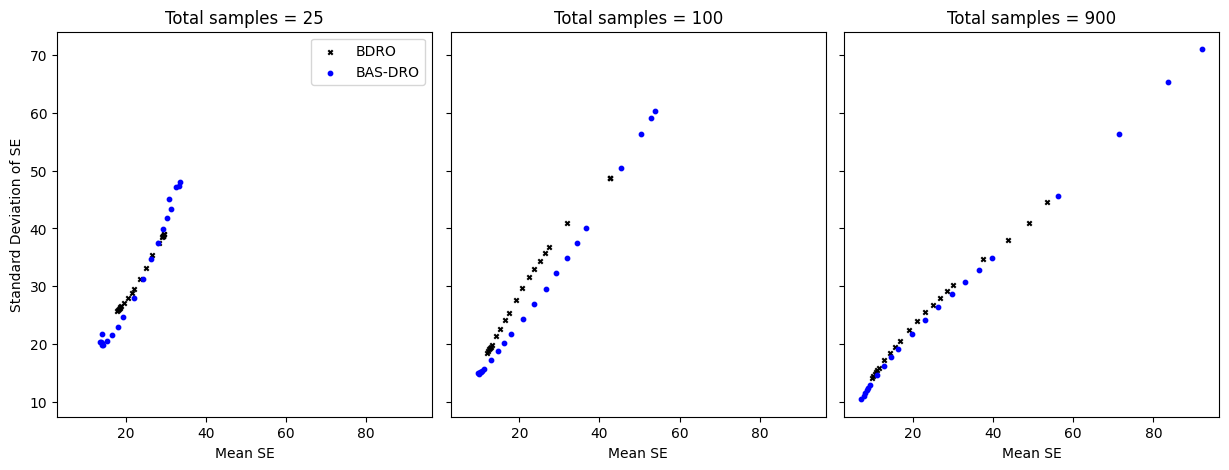

In [59]:
compare_col="algorithm"
gb_col="dgp"
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")
epsilons = np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 2.5, 3])

TOTAL_SAMPLES = [25, 100, 900]
# nrows = len(agg_df.index.get_level_values("dgp").unique())
nrows = 1
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    # gb = df.groupby(gb_col)
    
    bdro_mses = np.array(df["se"]["mean"]["kl_bdro"])
    bas_mses = np.array(df["se"]["mean"]["our_kl_bdro"])
    bdro_mses_var = np.array(df["se"]["std"]["kl_bdro"])
    bas_mses_var = np.array(df["se"]["std"]["our_kl_bdro"])
    
    axes[j].scatter(bdro_mses, bdro_mses_var, marker='x', label="BDRO", s=10, color='black')
    axes[j].scatter(bas_mses, bas_mses_var, label="BAS-DRO", s=10, color='blue')
    # axes[j].scatter(epsilons, bdro_mses, marker='x', label="BDRO", s=10, color='black')
    # axes[j].scatter(epsilons, bas_mses, label="BAS-DRO", s=10, color='blue')
    # axes[j].errorbar(epsilons, bdro_mses, yerr=bdro_mses_var, fmt='o', label='BDRO', alpha=0.6, capsize=5)
    # axes[j].errorbar(epsilons, bas_mses, yerr=bas_mses_var, fmt='x', label='BAS-DRO', alpha=0.6, capsize=5)
    if j==0:
        axes[j].legend()
        axes[j].set_ylabel('Standard Deviation of SE')
    axes[j].set_title(f'Total samples = {total_samples}')
    axes[j].set_xlabel('Mean SE')


In [60]:
row_names = [f"{epsilon}" for epsilon in epsilons]
df_mse = pd.DataFrame(index = row_names)
for i, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
    (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
     | (likelihood_sr == total_samples) & (posterior_sr == 1)
     )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
     # gb = df.groupby(gb_col)
    df = df.round(1)
    bdro_mses = np.array(df["se"]["mean"]["kl_bdro"])
    bas_mses = np.array(df["se"]["mean"]["our_kl_bdro"])
    bdro_mses_var = np.array(df["se"]["std"]["kl_bdro"])
    bas_mses_var = np.array(df["se"]["std"]["our_kl_bdro"])

    df_mse[f"Total samples {total_samples} (BAS-DRO)"] = [f"{bas_mses[j]} ({bas_mses_var[j]})" for j in range(len(epsilons))]
    df_mse[f"Total samples {total_samples} (BDRO)"] = [f"{bdro_mses[j]} ({bdro_mses_var[j]})" for j in range(len(epsilons))]

# Creating the DataFrame
# df = pd.DataFrame(data, index=[f"Epsilon {epsilon}" for epsilon in epsilons])
# df = pd.DataFrame(data)

# Display the DataFrame
# print(df.to_string(index=True))
df_mse

,Total samples 25 (BAS-DRO),Total samples 25 (BDRO),Total samples 100 (BAS-DRO),Total samples 100 (BDRO),Total samples 900 (BAS-DRO),Total samples 900 (BDRO)
0.05,14.0 (21.8),17.9 (25.6),9.6 (15.0),12.0 (18.5),7.1 (10.4),9.7 (14.2)
0.06,13.5 (20.3),18.1 (25.8),9.8 (14.8),12.2 (18.8),7.6 (11.0),10.1 (14.5)
0.07,13.8 (20.4),18.3 (26.1),10.1 (15.1),12.5 (19.2),8.0 (11.5),10.4 (14.9)
0.08,14.0 (20.2),18.5 (26.3),10.4 (15.2),12.7 (19.3),8.4 (12.0),10.7 (15.2)
0.09,14.2 (19.9),18.7 (26.4),10.7 (15.4),12.9 (19.6),8.8 (12.4),11.1 (15.5)
0.1,14.3 (19.9),18.8 (26.5),11.0 (15.6),13.2 (19.7),9.2 (12.8),11.4 (15.8)
0.15,15.4 (20.4),19.6 (27.1),12.9 (17.3),14.3 (21.3),11.1 (14.7),12.8 (17.2)
0.2,16.5 (21.5),20.7 (27.9),14.6 (18.8),15.2 (22.5),12.8 (16.3),14.1 (18.4)
0.25,18.0 (23.0),21.6 (28.9),16.2 (20.2),16.3 (24.1),14.5 (17.7),15.4 (19.5)
0.3,19.4 (24.7),22.2 (29.6),17.8 (21.7),17.3 (25.4),16.2 (19.1),16.6 (20.5)


In [7]:
# compare_col="algorithm"
# gb_col="dgp"
# likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
# posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

# total_samples = 900

# df = agg_df.loc[(
#         (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
#         | (likelihood_sr == total_samples) & (posterior_sr == 1)
#     )]
# df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
# # gb = df.groupby(gb_col)
# # gb
# df


se           
                          mean        std
algorithm   epsilon                      
kl_bdro     0.05      9.739607  14.186471
            0.06     10.070518  14.542914
            0.07     10.415676  14.874052
            0.08     10.722055  15.170700
            0.09     11.050683  15.501074
            0.10     11.366571  15.818074
            0.15     12.837678  17.219166
            0.20     14.146526  18.415579
            0.25     15.398871  19.511918
            0.30     16.604409  20.516745
            0.40     18.870888  22.337620
            0.50     20.992712  23.989187
            0.60     22.986707  25.454314
            0.70     24.861538  26.777913
            0.80     26.658357  28.000380
            0.90     28.374653  29.142685
            1.00     30.021778  30.199459
            1.50     37.435476  34.647359
            2.00     43.746560  38.021993
            2.50     48.940900  40.900882
            3.00     53.475976  44.498110
our_kl_bdro 0.05      7.080097  10.440100
            0.06      7.593070  11.047116
            0.07      8.009994  11.500695
            0.08      8.438838  11.989126
            0.09      8.835020  12.408550
            0.10      9.241394  12.833316
            0.15     11.078963  14.698717
            0.20     12.797082  16.262415
            0.25     14.509463  17.732985
            0.30     16.218691  19.139279
            0.40     19.616647  21.786027
            0.50     22.953169  24.165573
            0.60     26.324853  26.466283
            0.70     29.657347  28.638612
            0.80     32.997244  30.742372
            0.90     36.340986  32.839709
            1.00     39.700991  34.966202
            1.50     56.304151  45.692881
            2.00     71.428161  56.289112
            2.50     83.563810  65.333313
            3.00     92.248452  71.031779

In [9]:
# bdro_mses_25 = np.array(df["se"]["mean"]["kl_bdro"])
# bas_mses_25 = np.array(df["se"]["mean"]["our_kl_bdro"])
# bdro_mses_var_25 = np.array(df["se"]["var"]["kl_bdro"])
# bas_mses_var_25 = np.array(df["se"]["var"]["our_kl_bdro"])
# bdro_mses_100 = np.array(df["se"]["mean"]["kl_bdro"])
# bas_mses_100 = np.array(df["se"]["mean"]["our_kl_bdro"])
# bdro_mses_var_100 = np.array(df["se"]["var"]["kl_bdro"])
# bas_mses_var_100 = np.array(df["se"]["var"]["our_kl_bdro"])
bdro_mses_900 = np.array(df["se"]["mean"]["kl_bdro"])
bas_mses_900 = np.array(df["se"]["mean"]["our_kl_bdro"])
bdro_mses_var_900 = np.array(df["se"]["std"]["kl_bdro"])
bas_mses_var_900 = np.array(df["se"]["std"]["our_kl_bdro"])
epsilons = np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 2.5, 3])

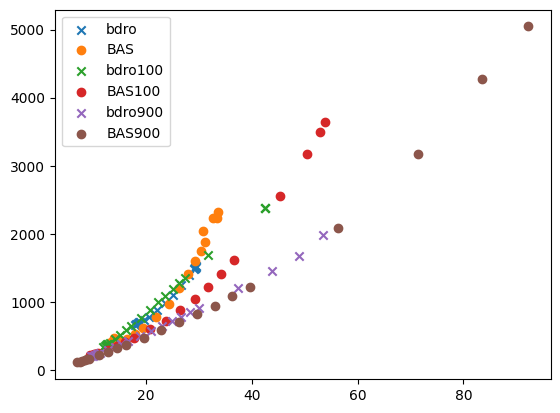

In [235]:
plt.scatter(bdro_mses_25, bdro_mses_var_25, marker='x', label="bdro")
plt.scatter(bas_mses_25, bas_mses_var_25, label="BAS")
plt.scatter(bdro_mses_100, bdro_mses_var_100,  marker='x',label="bdro100")
plt.scatter(bas_mses_100, bas_mses_var_100, label="BAS100")
plt.scatter(bdro_mses_900, bdro_mses_var_900,  marker='x',label="bdro900")
plt.scatter(bas_mses_900, bas_mses_var_900, label="BAS900")
plt.legend()

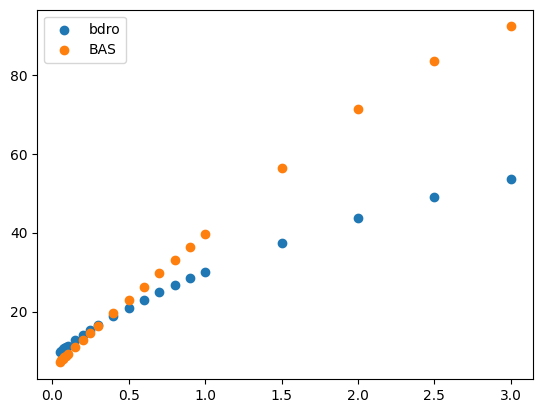

In [208]:

epsilons = np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 2.5, 3])

plt.scatter(epsilons, bdro_mses, label="bdro")
plt.scatter(epsilons, bas_mses, label="BAS")
plt.legend()

In [203]:
def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(dgp_precision * (beta_posterior / alpha_posterior))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / ( (beta_posterior / alpha_posterior))
    return 0.5*(term1 + term2 - 1) + get_kl_bdro_constant("normal_gamma", theta_params)

In [204]:
j = 9
generator = np.random.default_rng(seed=j)
data = sample_dgp(
        dgp, num_observations, generator=generator
    )
theta_prior = default_prior_params(posterior)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
print(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
print(expected_kl_normal_gamma(np.mean(data), np.std(data), theta_posterior))

0.0849102359630245
0.053069518958910655


In [181]:
from typing import Optional
import numpy as np
import scipy as sp


def default_prior_params(prior: str) -> tuple:
    """Get the default prior parameters"""
    prior_params = ()
    if prior == "gamma":
        alpha_prior, beta_prior = 1, 1
        prior_params = (alpha_prior, beta_prior)
    elif prior == "normal_gamma":
        mu_prior, kappa_prior, alpha_prior, beta_prior = 0.0, 1.0, 1.0, 1.0
        prior_params = (mu_prior, kappa_prior, alpha_prior, beta_prior)
    else:
        raise NotImplementedError(f"Prior '{prior}' not implemented.")
    return prior_params


def get_posterior_params(
    posterior: str, data: np.ndarray, prior_params: tuple
) -> tuple:
    """Given prior parameters, return the updated posterior parameters"""
    post_params = []
    if posterior == "gamma":
        alpha_prior, beta_prior = prior_params
        alpha_posterior = alpha_prior + data.shape[0]
        beta_posterior = beta_prior + np.sum(data)
        post_params = (alpha_posterior, beta_posterior)
    elif posterior == "normal_gamma":
        mu_prior, kappa_prior, alpha_prior, beta_prior = prior_params
        (
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
        ) = normal_gamma_posterior(data, mu_prior, kappa_prior, alpha_prior, beta_prior)
        post_params = (mu_posterior, kappa_posterior, alpha_posterior, beta_posterior)
    else:
        raise NotImplementedError(f"Posterior '{posterior}' is not implemented")
    return post_params


def derive_analytical_posterior_params(
    posterior: str, posterior_params: tuple
) -> np.ndarray:
    """When using our closed form expressions for 'Bayesian ambiguity sets',
    we derive a new distribution from the posterior parameters"""
    if posterior == "gamma":
        alpha_posterior, beta_posterior = posterior_params
        return np.array([alpha_posterior / beta_posterior])
    elif posterior == "normal_gamma":
        theta = np.zeros((1, 2))
        mu_posterior, _, alpha_posterior, beta_posterior = posterior_params
        # we want an analytical form for the precision, which is alpha over beta
        theta[0] = np.array([mu_posterior, alpha_posterior / beta_posterior])
        return theta
    else:
        raise NotImplementedError(
            f"We haven't derived an analytical posterior expression for a '{posterior}' posterior"
        )


def sample_posterior(
    posterior: str,
    posterior_params: tuple,
    num_posterior_samples: int,
    generator: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample from the posterior"""
    if posterior == "gamma":
        alpha_post, beta_post = posterior_params
        return sp.stats.gamma.rvs(
            a=alpha_post,
            scale=1 / beta_post,
            size=num_posterior_samples,
            random_state=generator,
        )
    if posterior == "normal_gamma":
        (
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
        ) = posterior_params
        return normal_gamma_rvs(
            num_posterior_samples,
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
            generator=generator,
        )
    else:
        raise NotImplementedError(f"Posterior '{posterior}' is not implemented")


def get_kl_bdro_constant(posterior: str, posterior_params: list) -> float:
    """Given the posterior params, return the optimization constant for Bayesian DRO"""
    if posterior == "gamma":
        alpha_posterior, _ = posterior_params
        return np.log(alpha_posterior) - sp.special.digamma(alpha_posterior)
    elif posterior == "normal_gamma":
        _, kappa_posterior, alpha_posterior, _ = posterior_params
        return get_normal_gamma_constant(alpha_posterior, kappa_posterior)
    else:
        raise NotImplementedError(f"get_kl_bdro_constant not implemented for posterior {posterior}")


def get_normal_gamma_constant(alpha: int, kappa: float) -> float:
    """Get the constant for normal-gamma DRO"""
    return 0.5 * (1 / kappa + np.log(alpha) - sp.special.digamma(alpha))


def normal_gamma_posterior(
    data: np.ndarray,
    mu_prior: float,
    kappa_prior: float,
    alpha_prior: float,
    beta_prior: float,
) -> tuple[float, float, float, float]:
    """Get the closed-form expression for normal-gamma posterior

    Returns:
        Posterior parameters for alpha, beta, mu, kappa

    Notes:
        See Section 3.3 of Murphy (2007).

    References:
        Murphy, K. P. (2007). Conjugate bayesian analysis of the gaussian distribution.
        Technical report, Department of Computer Science, The University of British Columbia.
    """
    num_observations = data.shape[0]
    data_mean = np.mean(data)
    mu_posterior = (kappa_prior * mu_prior + num_observations * data_mean) / (
        num_observations * kappa_prior
    )
    kappa_posterior = kappa_prior + num_observations
    alpha_posterior = alpha_prior + 0.5 * num_observations
    beta_posterior = (
        beta_prior
        + 0.5 * np.sum(np.square(data - data_mean))
        + (0.5 * num_observations * kappa_prior * np.square(data_mean - mu_prior))
        / (kappa_prior * num_observations)
    )
    return mu_posterior, kappa_posterior, alpha_posterior, beta_posterior


def normal_gamma_rvs(
    num_samples: int,
    mu: float,
    kappa: float,
    alpha: float,
    beta: float,
    generator: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Normal-gamma random variates

    Notes:
        1. Sample precision `lambda` from a Gamma(`alpha`, `beta`) distribution
        2. Sample from a normal distribution with mean `mu` and standard deviation `sqrt(1/(kappa * lambda))`
    """
    samples = np.zeros((num_samples, 2))
    if not generator:
        generator = np.random.default_rng()
    precision_samples = generator.gamma(alpha, 1.0 / beta, num_samples)
    for i in range(num_samples):
        # NOTE numpy Normal distribution takes standard deviation as a parameter (hence sqrt) - not variance!
        samples[i, 0] = generator.normal(
            mu, np.sqrt(1.0 / (kappa * precision_samples[i])), 1
        )
    samples[:, 1] = precision_samples
    return samples

In [179]:
from typing import Optional
import numpy as np
from scipy.stats import expon, gamma, norm

from bayesian_dro.Bayesian_DRO_continuous import data_generation, DGP_STD_TRUNCATED_NORMAL
def sample_dgp(
    dgp: str,
    num_observations: int,
    contamination: float = 0.0,
    generator: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample from the DGP"""
    if not generator:
        generator = np.random.default_rng()
    if dgp == "normal":
        return norm.rvs(
            loc=25,
            scale=DGP_STD_TRUNCATED_NORMAL,
            size=num_observations,
            random_state=generator,
        )
    if dgp == "truncated_normal":
        return data_generation(
            num_observations, random_state=generator
        )  # generate new observations
    if dgp == "contaminated_exp":
        # specify contamination level
        return data_generation_outliers(
            num_observations, contamination, random_state=generator
        )
    if dgp == "exponential":
        return expon.rvs(scale=20.0, size=num_observations, random_state=generator)
    if dgp == "gamma":
        return data_generation_gamma(num_observations, a=10, random_state=generator)
    raise ValueError(f"The data-generating process specified is not supported: {dgp}")